# (18) tbptt: ipc ($T_\text{train} = 64$)

**Motivation**: host = ```chewie```, device = ```cuda:0``` <br>

In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## Make a model

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('vH16-wht', model_type, 'ngd|lin')

cfg_vae['t_train'] = 64
cfg_vae['t_tbptt'] = 1
cfg_vae['kl_beta'] = 1.0

cfg_vae['fit_sigma'] = False
cfg_vae['fit_dt'] = False

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.n_iters

154500

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.1 K   |
|     ———     |    ———     |
|    layer    |  132.1 K   |
+-------------+------------+

poisson_vH16-wht_t-64_b-1_kms-(512,1,1)_<ngd|lin>
b200-ep300-lr(0.001)_temp(0.05)_gr(200)_(2025_08_18,15:16)

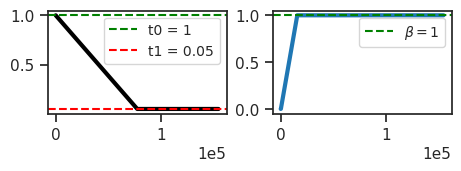

In [5]:
model.print()
tr.print()
tr.show_schedules()

In [6]:
model.layer.n_exp

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10], device='cuda:0',
       dtype=torch.int32)

In [7]:
print(f"{tr.model.layer}") # \n{tr.model.layer.dec}")

PoissonLayer(latent_sz=(512, 1, 1), input_sz=(1, 16, 16), temp=1)

In [8]:
print(f"\n\n{vars(tr.model.cfg)}\n\n{vars(tr.cfg)}\n")

{'prior_log_dist': 'uniform', 'clamp_prior': -4, 't_train': 64, 't_tbptt': 1, 'kl_beta': 1.0, 'latent_channels': 
512, 'latent_pixels': 1, 'latent_stride': 1, 'enc_type': 'ngd', 'dec_type': 'lin', 'recon_mode': 'mse', 'dataset': 
'vH16-wht', 'dataset_name': 'vH16-wht', 'feeder': 'stationary', 'feeder_cfg': {}, 'input_sz': (1, 16, 16), 
'latent_sz': (512, 1, 1), 'init_dist': 'normal', 'init_scale': 0.0001, 'clamp_vals': {'u': (7.0,), 'du': (5.0,), 
'dec': 3.45}, 'stochastic': True, 'optim_sigma': False, 'fit_sigma': False, 'fit_prior': True, 'fit_dt': False, 
'seed': 0, 'track_stats': False, 'base_dir': '/home/hadi/Projects/PoissonVAE', 'data_dir': '/home/hadi/Datasets', 
'runs_dir': '/home/hadi/Projects/PoissonVAE/runs/poisson_vH16-wht_t-64_b-1_kms-(512,1,1)_<ngd|lin>', 'mods_dir': 
'/home/hadi/Projects/PoissonVAE/models/poisson_vH16-wht_t-64_b-1_kms-(512,1,1)_<ngd|lin>', 'results_dir': 
'/home/hadi/Projects/PoissonVAE/results'}

{'lr': 0.001, 'epochs': 300, 'batch_size': 200, 'dataset_kws': None, 'warm_restart': 0, 'warmup_portion': 0.005, 
'optimizer': 'adamax_fast', 'optimizer_kws': {'weight_decay': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08}, 
'scheduler_type': 'cosine', 'scheduler_kws': {'T_max': 298.5, 'eta_min': 1e-06}, 'ema_rate': None, 'grad_clip': 
200, 'chkpt_freq': 50, 'eval_freq': 20, 'log_freq': 10, 'kl_beta_min': 0.0001, 'kl_const_portion': 0.001, 
'kl_anneal_portion': 0.1, 'temp_anneal_portion': 0.5, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 'temp_stop': 
0.05}

In [9]:
tr.train('ipc-t64')

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

epoch # 300, avg loss: 48.180: 100%|██████| 300/300 [15:39:49<00:00, 187.97s/it]


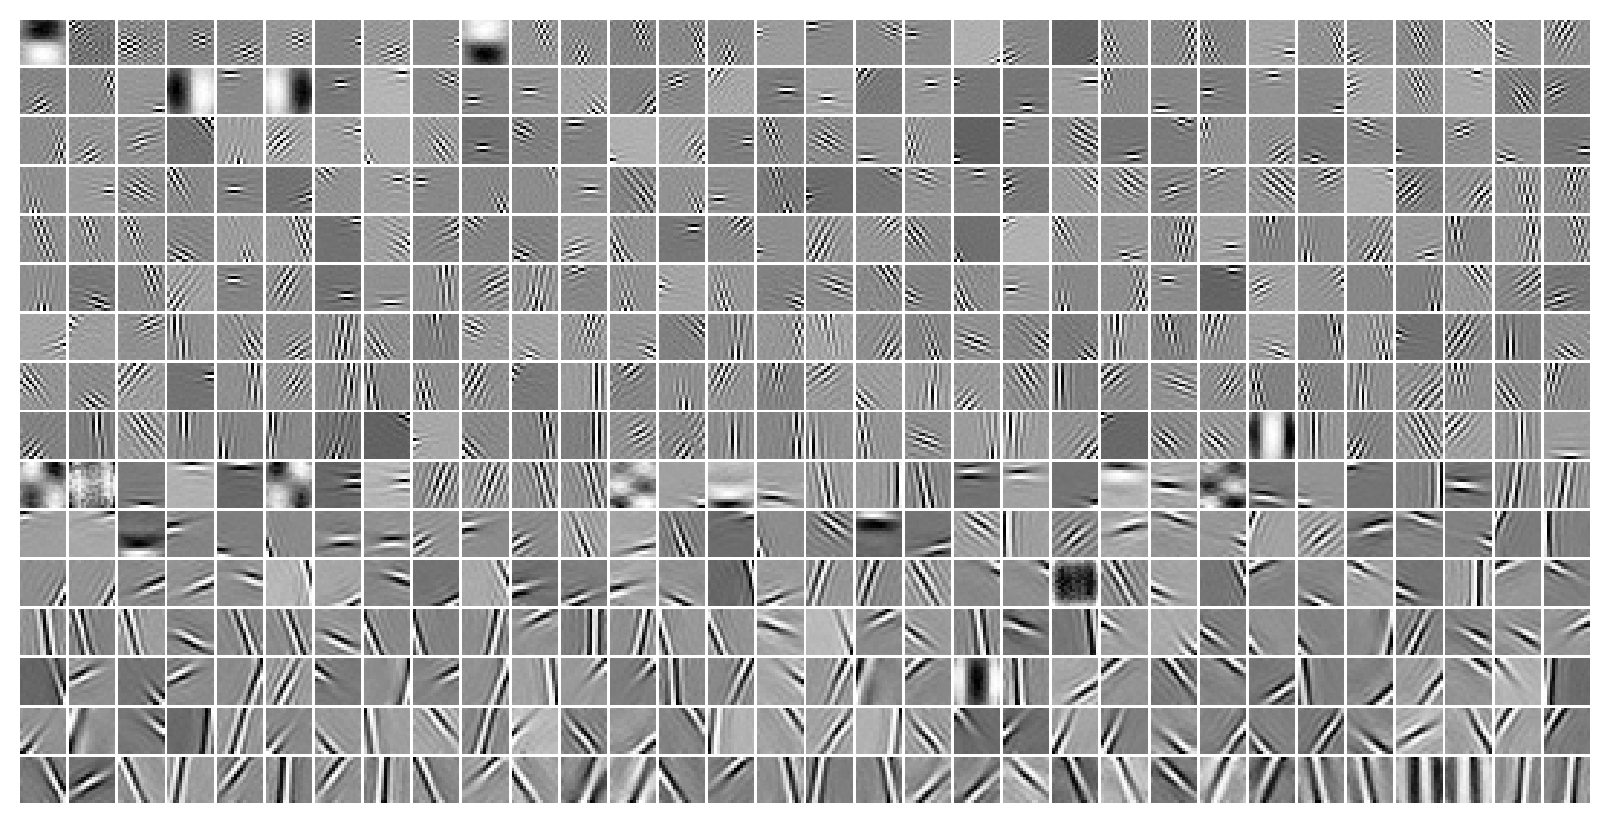

In [15]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

100%|███████████████████████████████████| 5/5 [02:01<00:00, 24.33s/it]


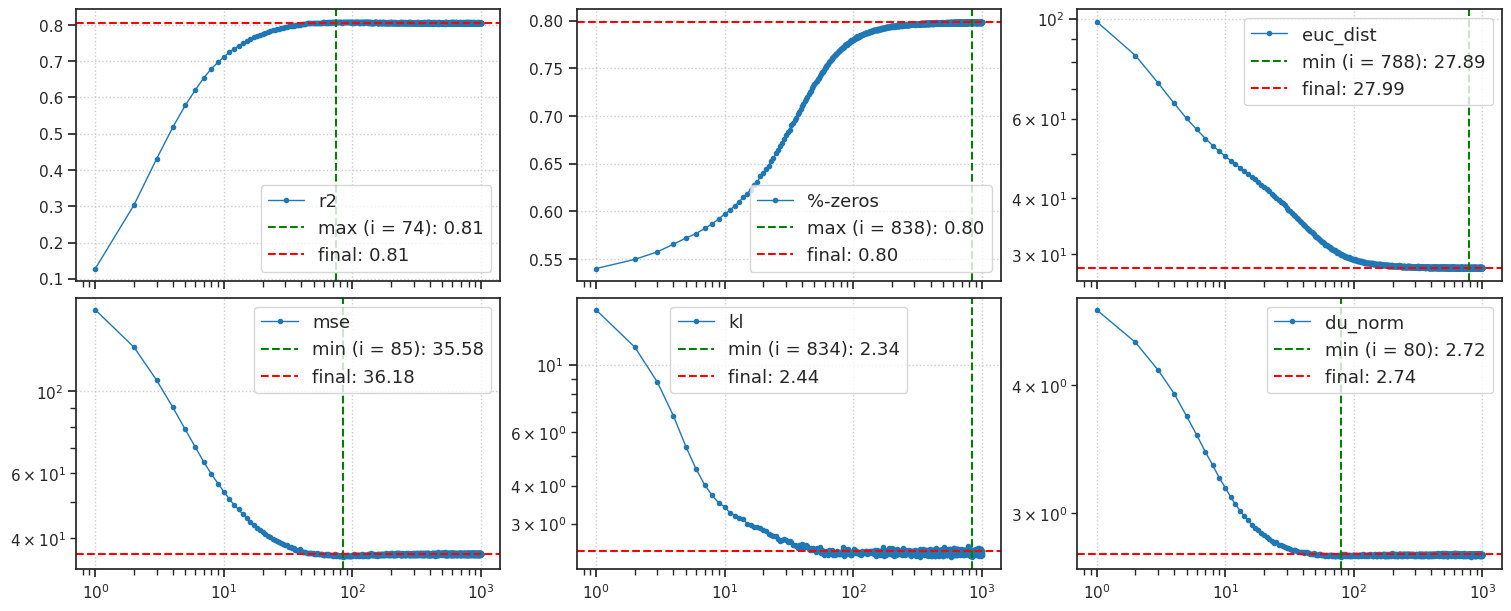

CPU times: user 2min 2s, sys: 15.8 ms, total: 2min 2s
Wall time: 2min 2s


In [16]:
%%time

kws = dict(t_total=1000, n_data_batches=5)
results = tr.analysis('vld', **kws)

items = ['r2', '%-zeros', 'euc_dist', 'mse', 'kl', 'du_norm']
_ = plot_convergence(results=results, items=items, color='C0')

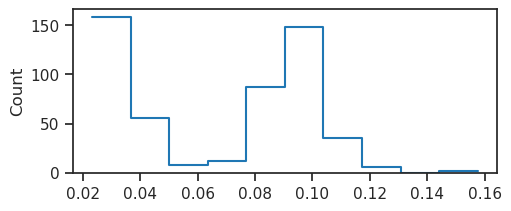

In [17]:
log_bias = tonp(tr.model.layer.log_bias.squeeze())
bias = np.exp(log_bias)

fig, ax = create_figure(1, 1, (5, 2))
histplot(bias.ravel())
plt.show()

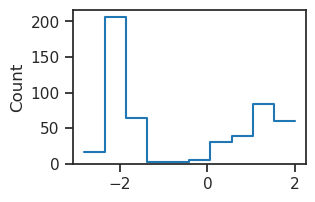

In [18]:
histplot(u0.ravel())
plt.show()

In [19]:
print(sp_stats.pearsonr(u0.ravel(), log_bias.ravel()))

PearsonRResult(statistic=-0.9955452, pvalue=0.0)